# Descargas

In [1]:
!pip install -qq umap-learn
!pip install gensim

___

In [2]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 9.4 MB/s  0:00:039.2 MB/s eta 0:00:01:02
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')


# Importaciones

### Configuración de nltk

In [1]:
import nltk
from nltk import word_tokenize
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
stopwords = nltk.corpus.stopwords.words('english')

### Configuración de spacy

In [2]:
import spacy
spacy.prefer_gpu()
nlp = spacy.load("en_core_web_md")

### Clasificadores

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import re
import time
import unicodedata

from string import punctuation
from sklearn.metrics import classification_report

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

___

# Descarga de corpus

In [5]:
!gdown 17W3bObZBL6XQVsVMSvkNildhsFSjsmhV

Downloading...
From: https://drive.google.com/uc?id=17W3bObZBL6XQVsVMSvkNildhsFSjsmhV
To: /home/Fer/Downloads/IMDB50K.csv
100%|██████████████████████████████████████| 66.2M/66.2M [00:03<00:00, 17.1MB/s]


In [6]:
df = pd.read_csv('IMDB50K.csv')
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [7]:
def normalizar_vector(v):
    if np.linalg.norm(v) == 0:
        return v
    else:
        return v / np.linalg.norm(v)

___

# Análisis exploratorio

## Limpieza de corpus

### Función de limpieza

In [8]:
def limpiar_texto(texto):

    if not isinstance(texto, str):
        return ""

    texto = texto.lower()
    # Quitar entidades HTML
    texto = re.sub(r'<[^>]*>', ' ', texto)
    # Quitar URLs
    texto = re.sub(r'https?://\S+|www\.\S+', '', texto)

    #Quitar hashtags
    texto = re.sub(r'#\S+', '', texto)

    # Quitar menciones
    texto = re.sub(r'@\S+', '', texto)

    # Quitar pixeles
    texto = re.sub(r'\d*\.?\d+\s*px', ' ', texto)

    # Quitar letras griegas
    texto = ''.join(char if not ('\u0370' <= char <= '\u03FF') else ' ' for char in texto)

    # Quitar caracteres raros (como 𖨆 y similares)
    texto = re.sub(r'[^a-zA-Z0-9áéíóúñüÁÉÍÓÚÑÜ\s\.\,\!\?\:\;]', ' ', texto)

    # Quitar caracteres de control
    texto = ''.join(char for char in texto if unicodedata.category(char)[0] != 'C')

    # Normalizar espacios
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

In [9]:
df["review"] = df["review"].apply(limpiar_texto)

In [10]:
df

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there s a family where a little boy ...,negative
4,petter mattei s love in the time of money is a...,positive
...,...,...
49995,i thought this movie did a down right good job...,positive
49996,"bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,i am a catholic taught in parochial elementary...,negative
49998,i m going to have to disagree with the previou...,negative


## Normalización

### Función de lematización

In [11]:
def clean_and_lemmatize(texts, disable_ner_parser=True):
    clean_texts = []
    for doc in nlp.pipe(texts, batch_size=2000, disable=["ner", "parser"] if disable_ner_parser else []):
        tokens = [
            token.lemma_.lower()
            for token in doc
            if not token.is_stop and token.is_alpha
        ]
        clean_texts.append(" ".join(tokens))
    return clean_texts

In [12]:
df['review'] = clean_and_lemmatize(df['review'].astype(str))

In [13]:
df

,review,sentiment
0,reviewer mention watch oz episode ll hook righ...,positive
1,wonderful little production film technique una...,positive
2,think wonderful way spend time hot summer week...,positive
3,basically s family little boy jake think s zom...,negative
4,petter mattei s love time money visually stunn...,positive
...,...,...
49995,think movie right good job wasn t creative ori...,positive
49996,bad plot bad dialogue bad acting idiotic direc...,negative
49997,catholic teach parochial elementary school nun...,negative
49998,m go disagree previous comment maltin second r...,negative


In [32]:
df.to_csv("IMDB_LEM.csv", index=False)

## Balance de clases

In [14]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Las clases ya se encuentran balanceadas

___

# División Train/Test

In [15]:
docs = df['review'].values
y = df['sentiment'].values

In [16]:
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train, y_test = train_test_split(docs, y,
                                                            test_size=0.20,
                                                            stratify=y,
                                                            random_state=642)

___

# Creando features con embeddings

## fastText

<b>¿Por qué fastText y no Word2vec?</b>
<p>fastText extiende Word2vec rompiendo las palabras en n-gramas de carácteres,
por lo que el vector de la palabra es la suma de los vectores de sus subpalabras.</p>
<p>Esto significa que puede trabajar con palabras OOV (Out Of Vocabulary) creando el vector de dicha palabra mediante vectores de subpalabras conocidas.</p>

### Entrenamiento

In [17]:
X_train_tokens = [review.split() for review in X_train_raw]

from gensim.models import FastText
ft_model = FastText(sentences=X_train_tokens,
                    vector_size=100,
                    window=5,
                    min_count=1,
                    epochs=10,
                    workers=4)

### Sets de train y test

In [18]:
def get_avg_vector(review, model, vector_size=100):
    tokens = review.split()
    vectors = [model.wv[token] for token in tokens if token in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

X_train_fast = np.array([get_avg_vector(review, ft_model) for review in X_train_raw])
X_test_fast = np.array([get_avg_vector(review, ft_model) for review in X_test_raw])

## Modelo preentranado word2vec-google-news-300

### Descarga del modelo

In [19]:
import gensim.downloader as api

w2v_model = api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


### Sets de train y test

In [20]:
def get_avg_vector(review, model, vector_size=100):
    tokens = review.split()

    wv = model.wv if hasattr(model, 'wv') else model
    vectors = [wv[token] for token in tokens if token in wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

X_train_w2v = np.array([get_avg_vector(review, w2v_model, vector_size=300) for review in X_train_raw])
X_test_w2v = np.array([get_avg_vector(review, w2v_model, vector_size=300) for review in X_test_raw])

## Doc2Vec

### Entrenamiento

In [21]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

train_tagged = [TaggedDocument(words=review.split(), tags=[i])
                for i, review in enumerate(X_train_raw)]

d2v_model = Doc2Vec(documents=train_tagged,
                    vector_size=100,
                    window=5,
                    min_count=1,
                    epochs=10,
                    workers=4)

### Sets de train y test

In [22]:
X_train_d2v = np.array([d2v_model.infer_vector(review.split()) for review in X_train_raw])
X_test_d2v = np.array([d2v_model.infer_vector(review.split()) for review in X_test_raw])

___

# Entrenamiento de modelos

## Logistic Regression

### fastText

In [23]:
lr_fast = LogisticRegression(max_iter=1000, random_state=642)
lr_fast.fit(X_train_fast, y_train)

y_pred_lr_fast = lr_fast.predict(X_test_fast)
print(classification_report(y_test, y_pred_lr_fast))

              precision    recall  f1-score   support

    negative       0.85      0.84      0.85      5000
    positive       0.84      0.85      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



### word2vec-google-news-300

In [24]:
lr_w2v = LogisticRegression(max_iter=1000, random_state=642)
lr_w2v.fit(X_train_w2v, y_train)

y_pred_lr_w2v = lr_w2v.predict(X_test_w2v)
print(classification_report(y_test, y_pred_lr_w2v))

              precision    recall  f1-score   support

    negative       0.86      0.84      0.85      5000
    positive       0.84      0.86      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



### Doc2Vec

In [25]:
lr_d2v = LogisticRegression(max_iter=1000, random_state=642)
lr_d2v.fit(X_train_d2v, y_train)

y_pred_lr_d2v = lr_d2v.predict(X_test_d2v)
print(classification_report(y_test, y_pred_lr_d2v))

              precision    recall  f1-score   support

    negative       0.83      0.84      0.84      5000
    positive       0.84      0.83      0.84      5000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



## Support Vector Machine (SVM)

### fastText

In [26]:
svm_fast = SVC(kernel='rbf', random_state=642)
svm_fast.fit(X_train_fast, y_train)

y_pred_svm_fast = svm_fast.predict(X_test_fast)
print(classification_report(y_test, y_pred_svm_fast))

              precision    recall  f1-score   support

    negative       0.86      0.85      0.86      5000
    positive       0.85      0.86      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



### word2vec-google-news-300

In [27]:
svm_w2v = SVC(kernel='rbf', random_state=642)
svm_w2v.fit(X_train_w2v, y_train)

y_pred_svm_w2v = svm_w2v.predict(X_test_w2v)
print(classification_report(y_test, y_pred_svm_w2v))

              precision    recall  f1-score   support

    negative       0.87      0.85      0.86      5000
    positive       0.85      0.87      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



### Doc2Vec

In [28]:
svm_d2v = SVC(kernel='rbf', random_state=642)
svm_d2v.fit(X_train_d2v, y_train)

y_pred_svm_d2v = svm_d2v.predict(X_test_d2v)
print(classification_report(y_test, y_pred_svm_d2v))

              precision    recall  f1-score   support

    negative       0.85      0.83      0.84      5000
    positive       0.84      0.86      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



## Random Forest

### fastText

In [29]:
rf_fast = RandomForestClassifier(n_estimators=100, random_state=642)
rf_fast.fit(X_train_fast, y_train)

y_pred_rf_fast = rf_fast.predict(X_test_fast)
print(classification_report(y_test, y_pred_rf_fast))

              precision    recall  f1-score   support

    negative       0.82      0.80      0.81      5000
    positive       0.81      0.82      0.82      5000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000



### word2vec-google-news-300

In [30]:
rf_w2v = RandomForestClassifier(n_estimators=100, random_state=642)
rf_w2v.fit(X_train_w2v, y_train)

y_pred_rf_w2v = rf_w2v.predict(X_test_w2v)
print(classification_report(y_test, y_pred_rf_w2v))

              precision    recall  f1-score   support

    negative       0.81      0.79      0.80      5000
    positive       0.80      0.82      0.81      5000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000



### Doc2Vec

In [31]:
rf_d2v = RandomForestClassifier(n_estimators=100, random_state=642)
rf_d2v.fit(X_train_d2v, y_train)

y_pred_rf_d2v = rf_d2v.predict(X_test_d2v)
print(classification_report(y_test, y_pred_rf_d2v))

              precision    recall  f1-score   support

    negative       0.80      0.80      0.80      5000
    positive       0.80      0.80      0.80      5000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



___

# Optimización de hiperparametros

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

from sklearn.metrics import f1_score, make_scorer
f1_scorer = make_scorer(f1_score, pos_label='positive')

# ---- Hyperparameter grids ----
lr_params = {
    'C': uniform(0.01, 10),
    'solver': ['lbfgs', 'liblinear', 'saga']
}

svm_params = {
    'C': uniform(0.01, 10),
    'kernel': ['rbf', 'linear', 'poly'],
    'gamma': ['scale', 'auto']
}

rf_params = {
    'n_estimators': randint(50, 300),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 10)
}

# ---- Logistic Regression ----
print("Optimizing Logistic Regression...")

lr_search_fast = RandomizedSearchCV(LogisticRegression(max_iter=1000, random_state=642), lr_params, n_iter=20, cv=5, scoring=make_scorer(f1_score, pos_label='positive'), random_state=642, n_jobs=-1)
lr_search_fast.fit(X_train_fast, y_train)
print(f"LR + FastText best params: {lr_search_fast.best_params_}")

lr_search_w2v = RandomizedSearchCV(LogisticRegression(max_iter=1000, random_state=642), lr_params, n_iter=20, cv=5, scoring=make_scorer(f1_score, pos_label='positive'), random_state=642, n_jobs=-1)
lr_search_w2v.fit(X_train_w2v, y_train)
print(f"LR + W2V best params: {lr_search_w2v.best_params_}")

lr_search_d2v = RandomizedSearchCV(LogisticRegression(max_iter=1000, random_state=642), lr_params, n_iter=20, cv=5, scoring=make_scorer(f1_score, pos_label='positive'), random_state=642, n_jobs=-1)
lr_search_d2v.fit(X_train_d2v, y_train)
print(f"LR + D2V best params: {lr_search_d2v.best_params_}")

# ---- SVM ----
print("Optimizing SVM...")

svm_search_fast = RandomizedSearchCV(SVC(random_state=642), svm_params, n_iter=20, cv=5, scoring=make_scorer(f1_score, pos_label='positive'), random_state=642, n_jobs=-1)
svm_search_fast.fit(X_train_fast, y_train)
print(f"SVM + FastText best params: {svm_search_fast.best_params_}")

svm_search_w2v = RandomizedSearchCV(SVC(random_state=642), svm_params, n_iter=20, cv=5, scoring=make_scorer(f1_score, pos_label='positive'), random_state=642, n_jobs=-1)
svm_search_w2v.fit(X_train_w2v, y_train)
print(f"SVM + W2V best params: {svm_search_w2v.best_params_}")

svm_search_d2v = RandomizedSearchCV(SVC(random_state=642), svm_params, n_iter=20, cv=5, scoring=make_scorer(f1_score, pos_label='positive'), random_state=642, n_jobs=-1)
svm_search_d2v.fit(X_train_d2v, y_train)
print(f"SVM + D2V best params: {svm_search_d2v.best_params_}")

# ---- Random Forest ----
print("Optimizing Random Forest...")

rf_search_fast = RandomizedSearchCV(RandomForestClassifier(random_state=642), rf_params, n_iter=20, cv=5, scoring=make_scorer(f1_score, pos_label='positive'), random_state=642, n_jobs=-1)
rf_search_fast.fit(X_train_fast, y_train)
print(f"RF + FastText best params: {rf_search_fast.best_params_}")

rf_search_w2v = RandomizedSearchCV(RandomForestClassifier(random_state=642), rf_params, n_iter=20, cv=5, scoring=make_scorer(f1_score, pos_label='positive'), random_state=642, n_jobs=-1)
rf_search_w2v.fit(X_train_w2v, y_train)
print(f"RF + W2V best params: {rf_search_w2v.best_params_}")

rf_search_d2v = RandomizedSearchCV(RandomForestClassifier(random_state=642), rf_params, n_iter=20, cv=5, scoring=make_scorer(f1_score, pos_label='positive'), random_state=642, n_jobs=-1)
rf_search_d2v.fit(X_train_d2v, y_train)
print(f"RF + D2V best params: {rf_search_d2v.best_params_}")

Optimizing Logistic Regression...


/home/Fer/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/Fer/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/Fer/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/Fer/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/Fer/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LR + FastText best params: {'C': np.float64(2.1257512161796486), 'solver': 'liblinear'}
LR + W2V best params: {'C': np.float64(8.59383448654845), 'solver': 'liblinear'}


/home/Fer/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/Fer/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/Fer/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/Fer/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LR + D2V best params: {'C': np.float64(9.26071523255529), 'solver': 'lbfgs'}
Optimizing SVM...


...

SVM + FastText best params: {'C': np.float64(8.447339654192904), 'gamma': 'scale', 'kernel': 'rbf'}


/home/Fer/miniconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


SVM + W2V best params: {'C': np.float64(9.880837210323888), 'gamma': 'scale', 'kernel': 'rbf'}


/home/Fer/miniconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


SVM + D2V best params: {'C': np.float64(0.8871702701119144), 'gamma': 'scale', 'kernel': 'rbf'}
Optimizing Random Forest...
RF + FastText best params: {'max_depth': 30, 'min_samples_split': 7, 'n_estimators': 201}
RF + W2V best params: {'max_depth': 30, 'min_samples_split': 8, 'n_estimators': 256}
RF + D2V best params: {'max_depth': 30, 'min_samples_split': 7, 'n_estimators': 244}


SVM + D2V best params: {'C': np.float64(0.8871702701119144), 'gamma': 'scale', 'kernel': 'rbf'}
Optimizing Random Forest...
RF + FastText best params: {'max_depth': 30, 'min_samples_split': 7, 'n_estimators': 201}
RF + W2V best params: {'max_depth': 30, 'min_samples_split': 8, 'n_estimators': 256}
RF + D2V best params: {'max_depth': 30, 'min_samples_split': 7, 'n_estimators': 244}

___

# Modelos optimizados

## Logistic Regression

In [37]:
print("=== Logistic Regression ===")
print("LR + FastText")
print(classification_report(y_test, lr_search_fast.best_estimator_.predict(X_test_fast)))
print("LR + W2V")
print(classification_report(y_test, lr_search_w2v.best_estimator_.predict(X_test_w2v)))
print("LR + D2V")
print(classification_report(y_test, lr_search_d2v.best_estimator_.predict(X_test_d2v)))

=== Logistic Regression ===
LR + FastText
              precision    recall  f1-score   support

    negative       0.85      0.84      0.85      5000
    positive       0.84      0.85      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000

LR + W2V
              precision    recall  f1-score   support

    negative       0.86      0.84      0.85      5000
    positive       0.85      0.86      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000

LR + D2V
              precision    recall  f1-score   support

    negative       0.83      0.84      0.84      5000
    positive       0.84      0.83      0.84      5000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg  

## Support Vector Machine (SVM)

In [38]:
print("=== SVM ===")
print("SVM + FastText")
print(classification_report(y_test, svm_search_fast.best_estimator_.predict(X_test_fast)))
print("SVM + W2V")
print(classification_report(y_test, svm_search_w2v.best_estimator_.predict(X_test_w2v)))
print("SVM + D2V")
print(classification_report(y_test, svm_search_d2v.best_estimator_.predict(X_test_d2v)))


=== SVM ===
SVM + FastText
              precision    recall  f1-score   support

    negative       0.86      0.86      0.86      5000
    positive       0.86      0.86      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000

SVM + W2V
              precision    recall  f1-score   support

    negative       0.87      0.85      0.86      5000
    positive       0.86      0.87      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000

SVM + D2V
              precision    recall  f1-score   support

    negative       0.85      0.83      0.84      5000
    positive       0.84      0.86      0.85      5000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84    

## Random Forest

In [39]:
print("=== Random Forest ===")
print("RF + FastText")
print(classification_report(y_test, rf_search_fast.best_estimator_.predict(X_test_fast)))
print("RF + W2V")
print(classification_report(y_test, rf_search_w2v.best_estimator_.predict(X_test_w2v)))
print("RF + D2V")
print(classification_report(y_test, rf_search_d2v.best_estimator_.predict(X_test_d2v)))

=== Random Forest ===
RF + FastText
              precision    recall  f1-score   support

    negative       0.83      0.79      0.81      5000
    positive       0.80      0.83      0.82      5000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000

RF + W2V
              precision    recall  f1-score   support

    negative       0.82      0.79      0.81      5000
    positive       0.80      0.83      0.81      5000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000

RF + D2V
              precision    recall  f1-score   support

    negative       0.81      0.80      0.80      5000
    positive       0.80      0.81      0.81      5000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0

Model                  Accuracy   F1 Score
------------------------------------------
LR + FastText            0.8485     0.8494
LR + W2V                 0.8517     0.8531
LR + D2V                 0.8372     0.8363
SVM + FastText           0.8606     0.8612
SVM + W2V                0.8619     0.8630
SVM + D2V                0.8440     0.8459
RF + FastText            0.8133     0.8172
RF + W2V                 0.8115     0.8150
RF + D2V                 0.8047     0.8056


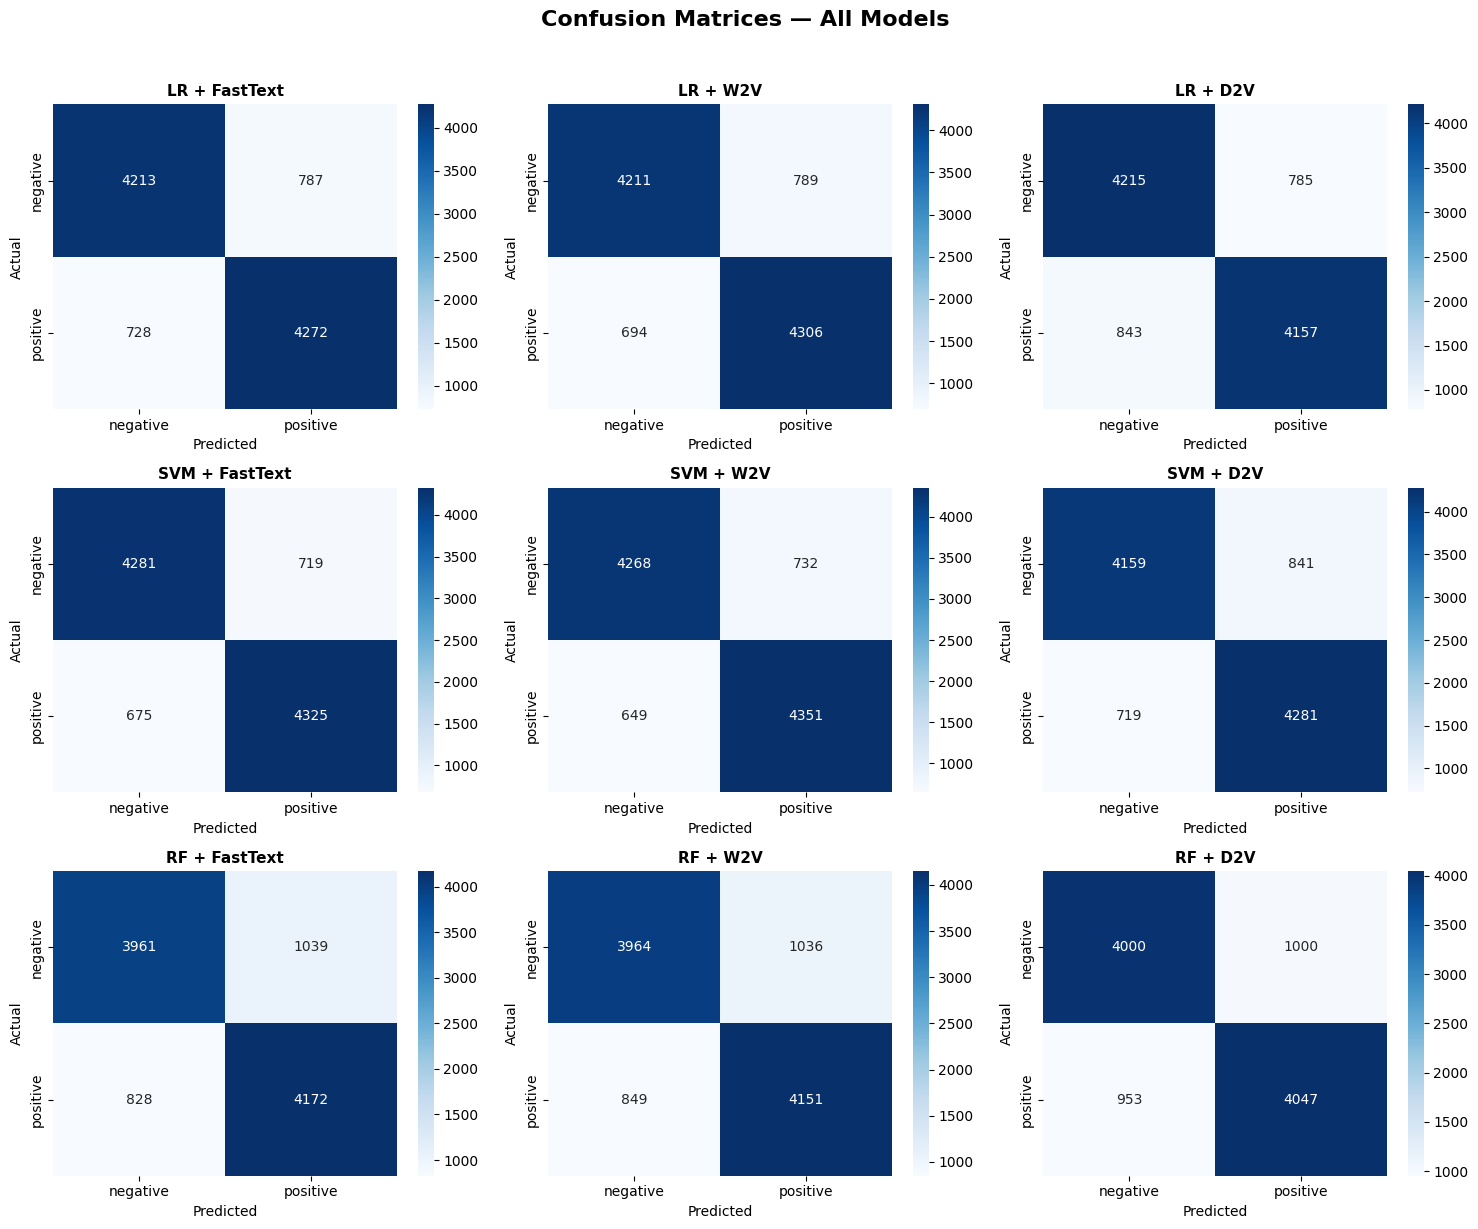

Saved as confusion_matrices.png


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np

models = {
    'LR + FastText':  (lr_search_fast.best_estimator_,  X_test_fast),
    'LR + W2V':       (lr_search_w2v.best_estimator_,   X_test_w2v),
    'LR + D2V':       (lr_search_d2v.best_estimator_,   X_test_d2v),
    'SVM + FastText': (svm_search_fast.best_estimator_, X_test_fast),
    'SVM + W2V':      (svm_search_w2v.best_estimator_,  X_test_w2v),
    'SVM + D2V':      (svm_search_d2v.best_estimator_,  X_test_d2v),
    'RF + FastText':  (rf_search_fast.best_estimator_,  X_test_fast),
    'RF + W2V':       (rf_search_w2v.best_estimator_,   X_test_w2v),
    'RF + D2V':       (rf_search_d2v.best_estimator_,   X_test_d2v),
}

# ── 1. Accuracy & F1 summary table ──────────────────────────────────────────
print(f"{'Model':<20} {'Accuracy':>10} {'F1 Score':>10}")
print("-" * 42)
for name, (model, X_test) in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, pos_label='positive')
    print(f"{name:<20} {acc:>10.4f} {f1:>10.4f}")

# ── 2. Confusion matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold', y=1.02)

for ax, (name, (model, X_test)) in zip(axes.flatten(), models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=['negative', 'positive'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['negative', 'positive'],
                yticklabels=['negative', 'positive'])
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as confusion_matrices.png")

___

# Mejor modelo

## Support Vector Machine (SVM) + word2vec-google-news-300

## 

   Best Model: SVM + word2vec-google-news-300

Best hyperparameters: {'C': np.float64(9.880837210323888), 'gamma': 'scale', 'kernel': 'rbf'}

Accuracy : 0.8619
F1 Score : 0.8630

Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.85      0.86      5000
    positive       0.86      0.87      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



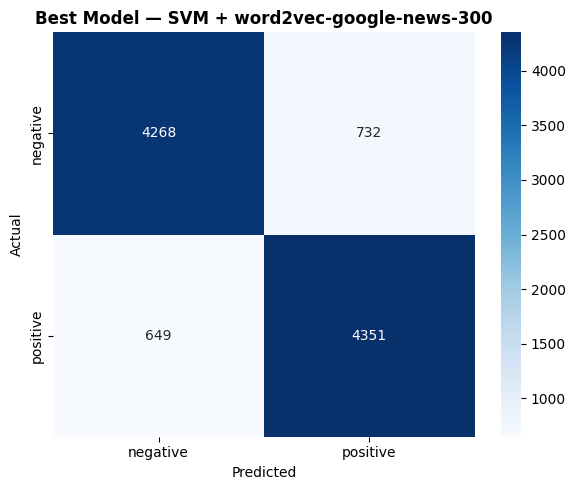

Saved as best_model_confusion_matrix.png


In [41]:
# ── Best Model: SVM + Word2Vec (word2vec-google-news-300) ───────────────────
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 55)
print("   Best Model: SVM + word2vec-google-news-300")
print("=" * 55)

# Predictions
y_pred_best = svm_search_w2v.best_estimator_.predict(X_test_w2v)

# Best hyperparameters
print(f"\nBest hyperparameters: {svm_search_w2v.best_params_}")

# Accuracy & F1
acc = accuracy_score(y_test, y_pred_best)
f1  = f1_score(y_test, y_pred_best, pos_label='positive')
print(f"\nAccuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")

# Full classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best, labels=['negative', 'positive'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
ax.set_title('Best Model — SVM + word2vec-google-news-300', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('best_model_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as best_model_confusion_matrix.png")

In [42]:
# ── False Positives & False Negatives samples ────────────────────────────────
import numpy as np

y_test_array = np.array(y_test)
X_test_raw_array = np.array(X_test_raw)

false_positives = X_test_raw_array[(y_pred_best == 'positive') & (y_test_array == 'negative')]
false_negatives = X_test_raw_array[(y_pred_best == 'negative') & (y_test_array == 'positive')]

print("=" * 55)
print("   False Positives (predicted positive, actually negative)")
print("=" * 55)
for i, sample in enumerate(false_positives[:2]):
    print(f"\nSample {i+1}:\n{sample}")

print("\n")
print("=" * 55)
print("   False Negatives (predicted negative, actually positive)")
print("=" * 55)
for i, sample in enumerate(false_negatives[:2]):
    print(f"\nSample {i+1}:\n{sample}")

   False Positives (predicted positive, actually negative)

Sample 1:
ok helicopter shot fantastic director good use barcelona s sight production value blow minute rest film feel like movie week ellen pompeo charming fun watch abel folk depth effective william baldwin william baldwin get martial art training good use run jump earnest action figure rest cast wooden good paper nostalgic spain s picture postcard action twist healthy dose el greco skip

Sample 2:
s kind fictionalized account barker gang get name right s russell hot ll grant real ma barker basically take care boy cook assisting move country plan participate crime think far interesting present real story middle aged woman catch criminal activity child crony agree reviewer find shoot scene totally unbelievable barker karpis victims combination innocent law enforcement agent pursue definitely mow half dozen fbi agent time corner hand recent book relate fbi era emphasize idea agent come legal accounting background extent agent 